# Background
This dataset contains transaction data from a fictitious SaaS company selling sales and marketing software to other companies (B2B). In the dataset, each row represents a single transaction/order (9,994 transactions), and the columns include:
1. Row ID: A unique identifier for each transaction.
2. Order ID: A unique identifier for each order.
3. Order Date: The date when the order was placed.
4. Date Key: A numerical representation of the order date (YYYYMMDD).
5. Contact Name: The name of the person who placed the order.
6. Country: The country where the order was placed.
7. City: The city where the order was placed.
8. Region: The region where the order was placed.
9. Subregion: The subregion where the order was placed.
10. Customer: The name of the company that placed the order.
11. Customer ID: A unique identifier for each customer.
12. Industry: The industry the customer belongs to.
13. Segment: The customer segment (SMB, Strategic, Enterprise, etc.).
14. Product: The product was ordered.
15. License: The license key for the product.
16. Sales: The total sales amount for the transaction.
17. Quantity: The total number of items in the transaction.
18. Discount: The discount applied to the transaction.
19. Profit: The profit from the transaction.

## Problem Statement
To understand the problem the company could be facing, we need to analyze the dataset first. The dataset can be accessed [here](https://www.kaggle.com/datasets/nnthanh101/aws-saas-sales).

# Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.stats import normaltest, chi2_contingency, mannwhitneyu, ttest_ind

import warnings
warnings.filterwarnings("ignore")

The following is the 5 top and 5 bottom rows from SaaS-Sales dataset.

In [2]:
# Load the CSV
df=pd.read_csv('SaaS-Sales.csv')
display(df.head(),df.tail())

,Row ID,Order ID,Order Date,Date Key,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit
0,1,EMEA-2022-152156,11/9/2022,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,Marketing Suite,16GRM07R1K,261.9600,2,0.00,41.9136
1,2,EMEA-2022-152156,11/9/2022,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,FinanceHub,QLIW57KZUV,731.9400,3,0.00,219.5820
2,3,AMER-2022-138688,6/13/2022,20220613,Deirdre Bailey,United States,New York City,AMER,NAMER,Phillips 66,1056,Energy,Strategic,FinanceHub,JI6BVL70HQ,14.6200,2,0.00,6.8714
3,4,EMEA-2021-108966,10/11/2021,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,ContactMatcher,DE9GJKGD44,957.5775,5,0.45,-383.0310
4,5,EMEA-2021-108966,10/11/2021,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,Marketing Suite - Gold,OIF7NY23WD,22.3680,2,0.20,2.5164


,Row ID,Order ID,Order Date,Date Key,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit
9989,9990,EMEA-2020-110422,1/22/2020,20200122,Dan Allan,Germany,Hamburg,EMEA,EU-WEST,Johnson & Johnson,1055,Healthcare,SMB,SaaS Connector Pack,ETHXMB5TMD,25.248,3,0.2,4.1028
9990,9991,AMER-2023-121258,2/27/2023,20230227,Anthony Sanderson,United States,Milwaukee,AMER,NAMER,American Express,1005,Finance,SMB,SaaS Connector Pack,LYHOKTRY7L,91.960,2,0.0,15.6332
9991,9992,AMER-2023-121258,2/27/2023,20230227,Anthony Sanderson,United States,Milwaukee,AMER,NAMER,American Express,1005,Finance,SMB,Site Analytics,I5SVMI6M88,258.576,2,0.2,19.3932
9992,9993,AMER-2023-121258,2/27/2023,20230227,Anthony Sanderson,United States,Milwaukee,AMER,NAMER,American Express,1005,Finance,SMB,Support,JHLW4P6LQ2,29.600,4,0.0,13.3200
9993,9994,AMER-2023-119914,5/5/2023,20230505,Jasmine Springer,United States,Dallas,AMER,NAMER,Comcast,1022,Communications,SMB,OneView,3NTBV9B3PS,243.160,2,0.0,72.9480


## Data Understanding and Cleaning
Before we analyze our data, we need to deep dive to understand it in *Data Understanding* and then any anomaly encountered will be handled in *Data Cleaning*. The way an anomaly is handled will be explained alongside its justification on why it is handled that way.

In [3]:
print(f'Number of rows and columns in df dataset: {df.shape}')
df.info()

Number of rows and columns in df dataset: (9994, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Row ID        9994 non-null   int64  
 1   Order ID      9994 non-null   object 
 2   Order Date    9994 non-null   object 
 3   Date Key      9994 non-null   int64  
 4   Contact Name  9994 non-null   object 
 5   Country       9994 non-null   object 
 6   City          9994 non-null   object 
 7   Region        9994 non-null   object 
 8   Subregion     9994 non-null   object 
 9   Customer      9994 non-null   object 
 10  Customer ID   9994 non-null   int64  
 11  Industry      9994 non-null   object 
 12  Segment       9994 non-null   object 
 13  Product       9994 non-null   object 
 14  License       9994 non-null   object 
 15  Sales         9994 non-null   float64
 16  Quantity      9994 non-null   int64  
 17  Discount      9994

In [4]:
display(df.describe(), df.describe(include='object'))

,Row ID,Date Key,Customer ID,Sales,Quantity,Discount,Profit
count,9994.000000,9.994000e+03,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2.021803e+07,1049.771963,229.858001,3.789574,0.156203,28.656896
std,2885.163629,1.123898e+04,29.719388,623.245101,2.225110,0.206452,234.260108
min,1.000000,2.020010e+07,1001.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2.021052e+07,1024.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2.022063e+07,1049.000000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2.023052e+07,1076.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2.023123e+07,1101.000000,22638.480000,14.000000,0.800000,8399.976000


,Order ID,Order Date,Contact Name,Country,City,Region,Subregion,Customer,Industry,Segment,Product,License
count,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994
unique,5009,1237,793,48,262,3,12,99,10,3,14,9994
top,EMEA-2023-100111,9/6/2022,Leonard Kelly,United States,London,EMEA,NAMER,Allianz,Finance,SMB,ContactMatcher,3NTBV9B3PS
freq,14,38,37,2001,922,4219,2507,192,2127,5191,1842,1


In [5]:
# unique data in each column
listItem = []
for col in df.columns :
    listItem.append( [col, df[col].nunique(), df[col].unique()])

table1Desc = pd.DataFrame(columns=['Column Name', 'Number of Unique', 'Unique Sample'],
                     data=listItem)
table1Desc

,Column Name,Number of Unique,Unique Sample
0,Row ID,9994,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
1,Order ID,5009,"[EMEA-2022-152156, AMER-2022-138688, EMEA-2021..."
2,Order Date,1237,"[11/9/2022, 6/13/2022, 10/11/2021, 6/9/2020, 4..."
3,Date Key,1237,"[20221109, 20220613, 20211011, 20200609, 20230..."
4,Contact Name,793,"[Nathan Bell, Deirdre Bailey, Zoe Hodges, Thom..."
5,Country,48,"[Ireland, United States, Germany, Sweden, Cana..."
6,City,262,"[Dublin, New York City, Stuttgart, Stockholm, ..."
7,Region,3,"[EMEA, AMER, APJ]"
8,Subregion,12,"[UKIR, NAMER, EU-WEST, NOR, JAPN, EU, MEA, LAT..."
9,Customer,99,"[Chevron, Phillips 66, Royal Dutch Shell, BNP ..."


From what we can see, we can conclude:
* There is no missing value, every row has been filled (9994)
* `Order Date` is object type, so it should be changed into date type
* All numeric column is already either integer or float
* `Sales`, `Discount`, and `Profit` ranges seem to be pretty wide
* `Row ID` is unique while `Order ID` is not, as it should be for an order to purchase different `Product`
* Also, `License` is unique

Based on the initial data exploration, it appears that the company’s profitability is highly inconsistent. Perhaps the presence of high discount levels and a number of transactions with negative profit suggests that certain pricing strategies or customer groups may be reducing overall profit margins. Therefore, in order to optimize revenue and make data-driven business decisions, the company needs to understand how discounts, customer characteristics, and regional differences are affecting both sales and profitability.

### Business Questions
* Which subregions show strong or weak sales and profitability?
* Which customer segments and industries contribute the most or least profit?
* Which products generate losses or low profit despite high sales?
* How do discounts affect profit margins?
* Based on the findings, what recommendations can improve profitability (reduce discount, target segment, etc.)?

### Data Cleaning
Before we do the analysis, we should first clean our dataset first. Thankfully, there is no missing value, so the only thing we need to do is to convert the `Order Date` from object to datetime.

#### Convert `Order Date` to datetime
This needs to be done if we are to do a time-based analysis.

In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Row ID        9994 non-null   int64         
 1   Order ID      9994 non-null   object        
 2   Order Date    9994 non-null   datetime64[ns]
 3   Date Key      9994 non-null   int64         
 4   Contact Name  9994 non-null   object        
 5   Country       9994 non-null   object        
 6   City          9994 non-null   object        
 7   Region        9994 non-null   object        
 8   Subregion     9994 non-null   object        
 9   Customer      9994 non-null   object        
 10  Customer ID   9994 non-null   int64         
 11  Industry      9994 non-null   object        
 12  Segment       9994 non-null   object        
 13  Product       9994 non-null   object        
 14  License       9994 non-null   object        
 15  Sales         9994 non-null   float64 

#### Outliers
Due to the nature of SaaS dataset, outliers are not removed because they represent real business transactions such as heavy discounting or loss-making deals. Removing them would hide important patterns in pricing and profitability.

#### New Columns: Profit Margin
We need to create new columns for profit margin. Profit Margin will be the main metric to evaluate profitability.

In [7]:
# Create Profit Margin column
df['Profit Margin'] = df['Profit'] / df['Sales']

# In case of Sales = 0, this code will handle it
df['Profit Margin'].replace([float('inf'), -float('inf')], 0, inplace=True)

df.head()

,Row ID,Order ID,Order Date,Date Key,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit,Profit Margin
0,1,EMEA-2022-152156,2022-11-09,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,Marketing Suite,16GRM07R1K,261.9600,2,0.00,41.9136,0.1600
1,2,EMEA-2022-152156,2022-11-09,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,FinanceHub,QLIW57KZUV,731.9400,3,0.00,219.5820,0.3000
2,3,AMER-2022-138688,2022-06-13,20220613,Deirdre Bailey,United States,New York City,AMER,NAMER,Phillips 66,1056,Energy,Strategic,FinanceHub,JI6BVL70HQ,14.6200,2,0.00,6.8714,0.4700
3,4,EMEA-2021-108966,2021-10-11,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,ContactMatcher,DE9GJKGD44,957.5775,5,0.45,-383.0310,-0.4000
4,5,EMEA-2021-108966,2021-10-11,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,Marketing Suite - Gold,OIF7NY23WD,22.3680,2,0.20,2.5164,0.1125


# Data Analysis
Now that we've done Data Understanding and Cleaning, we can proceed to Data Analysis.

## Subregions
Our first order of business is to evaluate which **geographic markets** contribute the most to sales and profitability. The dataset provides three levels of geographic detail: `Region`, `Subregion`, and `Country`. Among these, `Subregion` offers the most meaningful granularity for analysis. Why subregions?
* `Region` contains only three categories (EMEA, AMER, APJ). While `Region` can be used for a high-level overview, it is too broad to capture meaningful differences in market performance. Each `Region` combines many very different countries and customer behaviors, which can hide important patterns.
*  `Country` contains 48 categories, which is too detailed for clear analysis. Using Country-level data would produce crowded tables and charts, and many countries may have too few transactions to form reliable insights. This can introduce statistical noise and make it harder to identify business-relevant trends.
* `Subregion` provides a balanced middle ground, with 12 categories such as UKIR, EU-WEST, NAMER, ASEAN, and LATAM. This level is granular enough to reveal differences in market performance, but manageable enough to visualize clearly. It allows us to identify which specific market groups show strong sales, weak profitability, or heavy reliance on discounts.

For these reasons, `Subregion` is the most suitable geographic dimension for understanding the company’s market performance and identifying areas where profitability can be improved.

This analysis helps answer the business question: “Which subregions show strong or weak sales and profitability?”

### Total Sales and Profit by Subregion

In [8]:
subregion_summary = df.groupby('Subregion')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)
subregion_summary

,Sales,Profit
Subregion,,
NAMER,596328.9015,109784.0388
EU-WEST,384065.6140,26706.6029
UKIR,347468.0210,85238.2452
LATAM,241520.7030,17642.9510
JAPN,170188.0458,-25729.3563
NOR,127326.9600,16044.7604
APAC,106771.2120,30311.1778
ANZ,84949.6230,-11450.7709
MEA,76793.6960,7200.1468


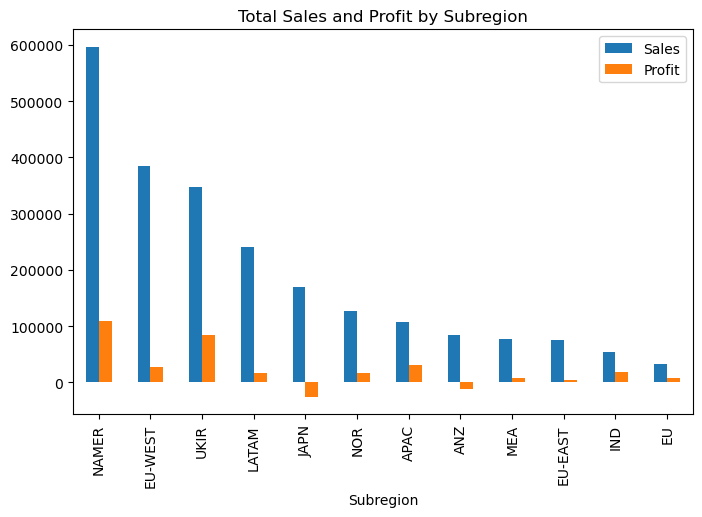

In [9]:
subregion_summary.plot(
    kind='bar',
    figsize=(8,5),
    title='Total Sales and Profit by Subregion')
plt.show()

Interpretation:
* `NAMER` is the largest and most profitable market, followed by `UKIR`.
* `JAPN` and `ANZ` profits are in the **negative**.

### Average Profit Margin by Subregion

In [10]:
subregion_margin = df.groupby('Subregion')['Profit Margin'].mean().sort_values(ascending=False)
subregion_margin

Subregion
IND        0.347852
APAC       0.336265
EU         0.317909
UKIR       0.302176
NAMER      0.277934
MEA        0.176588
NOR        0.169609
LATAM      0.090615
EU-EAST    0.090362
EU-WEST    0.071539
JAPN      -0.342011
ANZ       -0.343492
Name: Profit Margin, dtype: float64

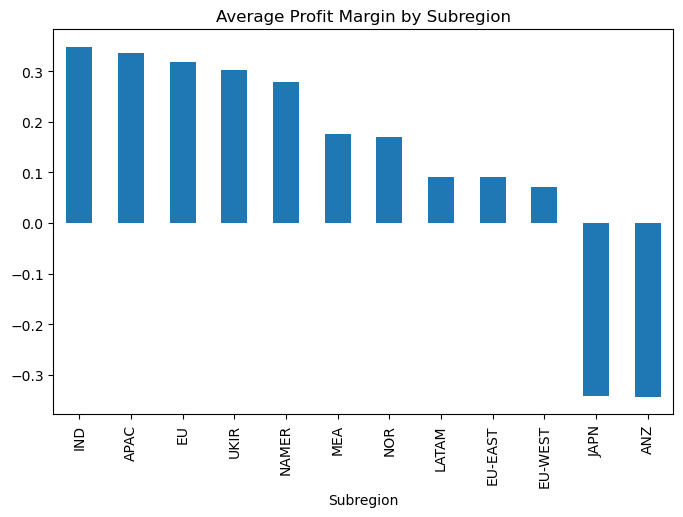

In [11]:
subregion_margin.plot(
    kind='bar',
    figsize=(8,5),
    title='Average Profit Margin by Subregion')
plt.show()

Interpretation:
* `IND` has the **highest margin** but also **low sales**.
* `APAC`, `EU`, `UKIR`, and `NAMER` are efficient and have decent `Sales`.
* `JAPN` and `ANZ` have **negative margin**, losing money on average per transaction.

### Visualizing Profit Margin Distribution by Subregion

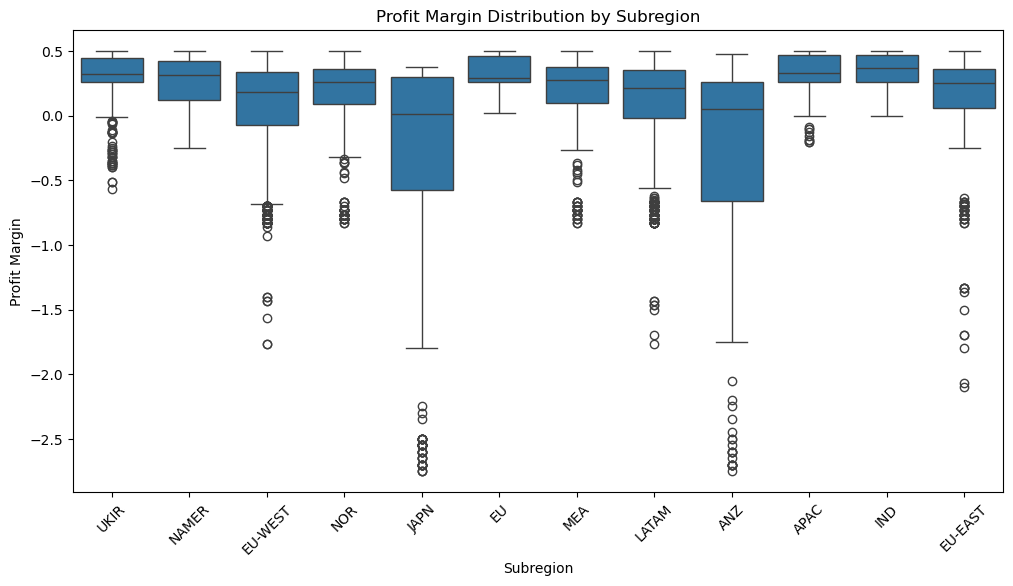

In [12]:
plt.figure(figsize = (12,6))
sns.boxplot(data = df,
            x = 'Subregion',
            y = 'Profit Margin')
plt.xticks(rotation = 45)
plt.title('Profit Margin Distribution by Subregion')
plt.show()

In each boxplot, the box represents the middle 50% of values, the line shows the median, and dots represent unusually high or low margins.
Interpretation:

**JAPN and ANZ**:
* Very wide spread.
* Many strongly negative outliers.
* Median profit margin near or on zero.

**IND, APAC, UKIR, and EU**:
* High median profit margin
* Tight distribution

### Combining sales and margin into a single summary table

In [13]:
subregion_full = df.groupby('Subregion').agg({
    'Sales':'sum',
    'Profit':'sum',
    'Profit Margin':'mean'
}).sort_values('Sales', ascending=False)

subregion_full

,Sales,Profit,Profit Margin
Subregion,,,
NAMER,596328.9015,109784.0388,0.277934
EU-WEST,384065.6140,26706.6029,0.071539
UKIR,347468.0210,85238.2452,0.302176
LATAM,241520.7030,17642.9510,0.090615
JAPN,170188.0458,-25729.3563,-0.342011
NOR,127326.9600,16044.7604,0.169609
APAC,106771.2120,30311.1778,0.336265
ANZ,84949.6230,-11450.7709,-0.343492
MEA,76793.6960,7200.1468,0.176588


### Subregions Insight
The results show that sales and profitability vary significantly across subregions. `NAMER` is the company’s **largest market** in terms of revenue (≈596K USD) and also generates strong profit. However, `UKIR`, `APAC`, `IND`, and `EU` subregion demonstrate **healthy profit margins**, indicating stable and efficient market performance.

In contrast, several subregions contribute high sales but produce relatively weak profitability. `EU-WEST` generates the second-highest revenue but has a very low average profit margin (7%), suggesting heavy discounting or low-margin customers.

But the most concerning finding is that `JAPN` and `ANZ` have **negative average profit margins**, meaning the company is losing money on transactions in these markets. The boxplot confirms this by showing wide margin variability and a large number of negative-margin outliers.

Overall, the analysis indicates that the company’s profitability is highly inconsistent across subregions. While some markets are stable and efficient, others suffer from low margins or even losses. These findings highlight the need for targeted pricing and discount strategy improvements in underperforming subregions.

## Customer Segment and Industry
After understanding geographic performance, the next step is to analyze **customer characteristics** to determine which types of customers drive the company’s profitability. The dataset contains two important fields for this:

* `Segment` (SMB, Enterprise, Strategic)
* `Industry` (various B2B industries such as `Finance`, `Tech`, `Healthcare`, etc.)

Customer `Segment` gives a high-level grouping of business types, while `Industry` provides a more detailed breakdown. Together, these dimensions help answer the business question:

“Which customer segments and industries contribute the most or least profit?”

### Total Sales and Profit by Segment

In [14]:
segment_summary = df.groupby('Segment')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)
segment_summary

,Sales,Profit
Segment,,
SMB,1.161401e+06,134119.2092
Strategic,7.061464e+05,91979.1340
Enterprise,4.296531e+05,60298.6785


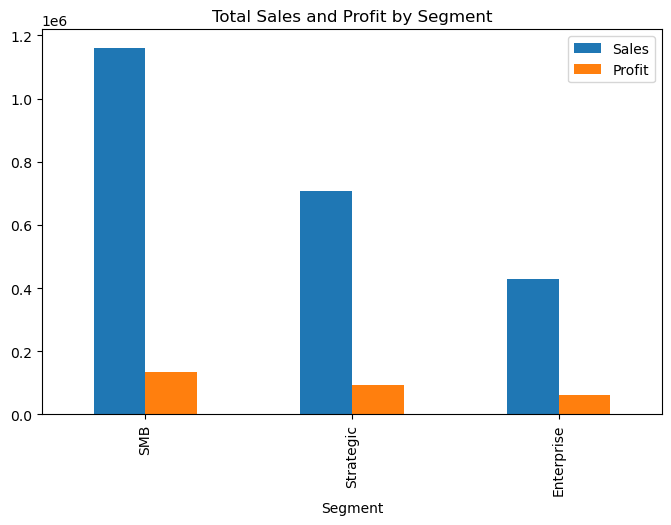

In [15]:
segment_summary.plot(
    kind='bar',
    figsize=(8,5),
    title='Total Sales and Profit by Segment')
plt.show()

Interpretation:

`SMB` is the **largest revenue** and profit contributor, bringing **2-3x more sales** than the other segments.

### Average Profit Margin by Segment

In [16]:
segment_margin = df.groupby('Segment')['Profit Margin'].mean().sort_values(ascending=False)
segment_margin

Segment
Enterprise    0.142870
Strategic     0.121203
SMB           0.112050
Name: Profit Margin, dtype: float64

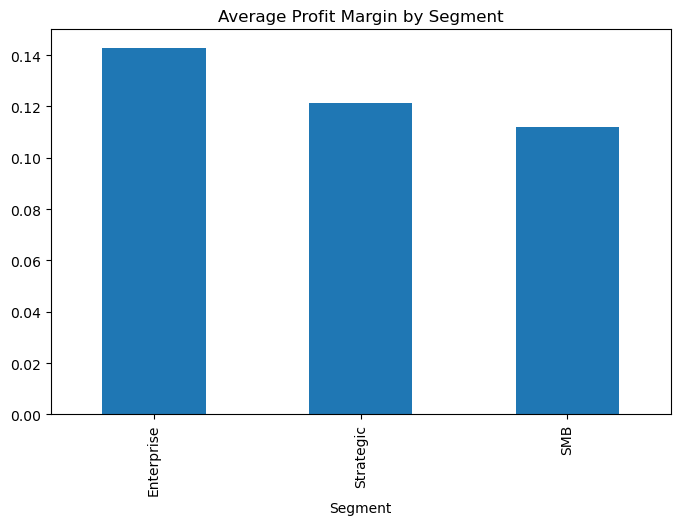

In [17]:
segment_margin.plot(
    kind='bar',
    figsize=(8,5),
    title='Average Profit Margin by Segment')
plt.show()

Interpretation:
* `Enterprise` customers are the **most profitable**, as they likely to buy high-value products with stable margins.
* `SMB` has the **lowest margin**. They may tend to buy low-margin products and requires heavier discounting

Interpretation for Customer Segment:

Revenue concentration in `SMB` combined with lower profit margins suggests pricing pressure in the `SMB` segment. Meanwhile, `Enterprise` customers, although fewer, deliver higher efficiency and margin stability.

### Total Sales and Profit by Industry

In [18]:
industry_summary = df.groupby('Industry')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)
industry_summary

,Sales,Profit
Industry,,
Finance,474150.4844,50348.9696
Energy,304644.1409,45282.3137
Manufacturing,295192.3812,38413.1064
Healthcare,273183.2882,31969.0932
Tech,263169.0277,24615.0436
Consumer Products,224044.1422,37018.0077
Retail,223072.0720,30207.8208
Communications,120962.2365,13976.3410
Transportation,90191.3276,7402.6967


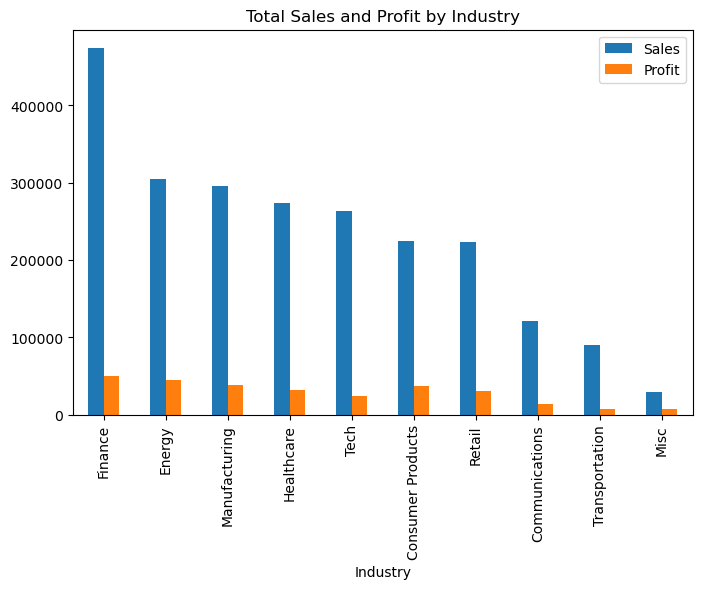

In [19]:
industry_summary.plot(
    kind='bar',
    figsize=(8,5),
    title='Total Sales and Profit by Industry')
plt.show()

Interpretation:
* `Finance` is the **largest industry** and a **solid profit contributor**.
* Behind it, `Energy` and `Manufacturing` also provide **strong revenue** and **profit**.
* `Misc`, `Transportation`, and `Communications` industries are small niches with **low total sales**.

### Average Profit Margin by Industry

In [20]:
industry_margin = df.groupby('Industry')['Profit Margin'].mean().sort_values(ascending=False)
industry_margin

Industry
Misc                 0.139836
Manufacturing        0.133272
Retail               0.132463
Finance              0.121523
Tech                 0.119459
Energy               0.119071
Healthcare           0.118411
Communications       0.112310
Consumer Products    0.104995
Transportation       0.099722
Name: Profit Margin, dtype: float64

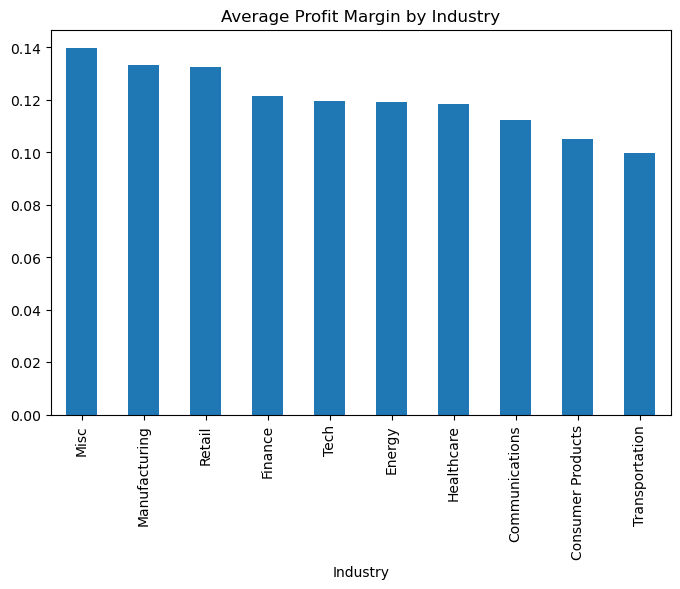

In [21]:
industry_margin.plot(
    kind='bar',
    figsize=(8,5),
    title='Average Profit Margin by Industry')
plt.show()

Interpretation:
* Although `Misc` has the **highest margin**, its **revenue is too low** (only 28K in `Sales`).
* `Manufacturing` and `Retail` have **high profit margins**.
* `Consumer Products` and `Transportation` have **weak margins**.
* `Finance`, `Tech`, `Energy`, and `Healthcare` have good, average margins.

Interpretation for Industry:
* `Finance` is the **largest market** but not the most margin-efficient.
* `Manufacturing` has  **good revenue** with **strong margins**.
* `Transportation` **underperforms** both in `Sales` and `Profit Margin`.

### Customer Segment and Industry Insight
The analysis of **customer characteristics** reveals clear differences in profitability across both `Segment` and `Industry`. `SMB` represents **the company’s largest revenue source** but also shows the lowest `Profit Margin`, indicating pricing pressure or reliance on high-discount deals. `Enterprise` customers, although fewer, deliver the **highest average margin**, suggesting greater pricing stability and more profitable transactions.

Industry-level performance also varies substantially. `Finance` is the **largest revenue contributor**, while `Manufacturing` and `Retail` achieve the **strongest profit margins**. Conversely, `Consumer Products` and `Transportation` deliver both **low revenue** and **weak margins**, indicating underperformance in those markets. These findings show that both customer profile and industry type significantly influence profitability and should be considered when evaluating pricing strategy and market focus.

## Product Performance
After analyzing **subregions** and **customer characteristics**, the next step is to evaluate the performance of the company’s **products**. Different products may vary widely in both sales volume and profitability. Some products may generate high sales but low margins, while others may contribute disproportionately to losses due to excessive discounting or low pricing efficiency.

This analysis helps answer the business question:

“Which products generate losses or low profit despite high sales?”

### Total Sales and Profit by Product

In [22]:
product_summary = df.groupby('Product')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)
product_summary

,Sales,Profit
Product,,
ContactMatcher,410378.2650,12496.2822
FinanceHub,340935.4150,32136.4203
Site Analytics,330007.0540,44515.7306
Marketing Suite - Gold,223843.6080,21278.8264
Big Ol Database,189238.6310,3384.7569
Data Smasher,167380.3180,41936.6357
Alchemy,149528.0300,55617.8249
Support,125152.7440,32864.4698
Marketing Suite,114879.9963,-3472.5560


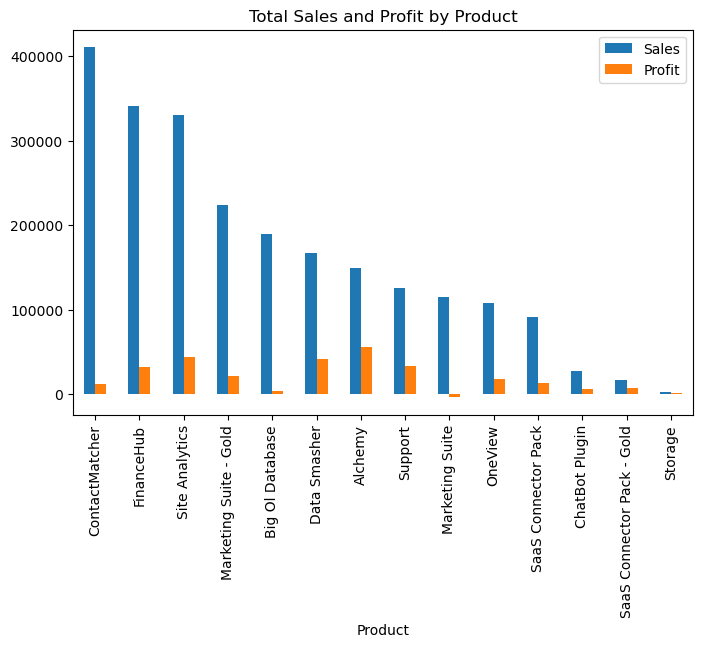

In [23]:
product_summary.plot(
    kind='bar',
    figsize=(8,5),
    title='Total Sales and Profit by Product')
plt.show()

Interpretation:
* The top 3 selling products are `ContactMatcher`, `FinanceHub`, and `Site Analytics`.
* The products with lowest sales are `Storage`, `SaaS Connector Pack - Gold`, and `ChatBot Plugin`.

### Average Profit Margin by Product

In [24]:
product_margin = df.groupby('Product')['Profit Margin'].mean().sort_values(ascending=False)
product_margin

Product
SaaS Connector Pack - Gold    0.423140
Support                       0.387410
Alchemy                       0.317194
Storage                       0.299171
ChatBot Plugin                0.251646
Data Smasher                  0.218210
FinanceHub                    0.187037
SaaS Connector Pack           0.137066
Site Analytics                0.119222
Marketing Suite - Gold        0.089113
Big Ol Database              -0.072026
Marketing Suite              -0.126640
OneView                      -0.156869
ContactMatcher               -0.190612
Name: Profit Margin, dtype: float64

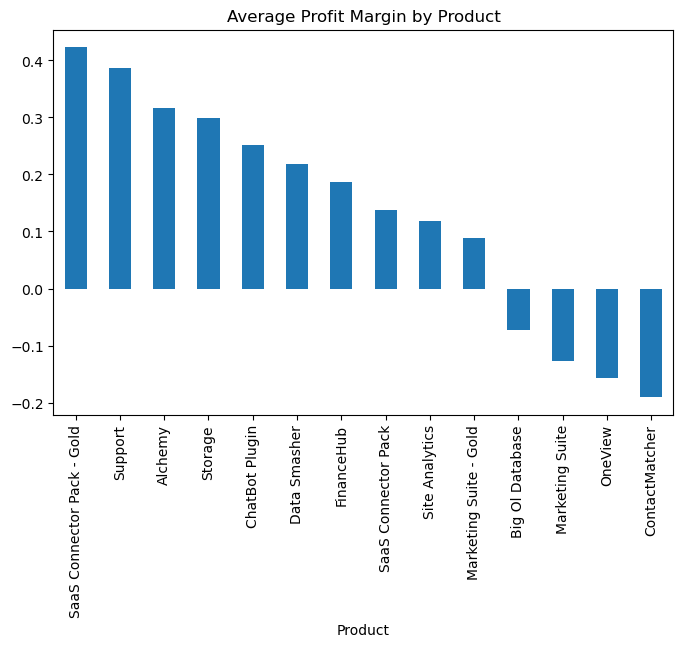

In [25]:
product_margin.plot(
    kind='bar',
    figsize=(8,5),
    title='Average Profit Margin by Product')
plt.show()

Interpretation:
* `SaaS Connector Pack – Gold` is the highest margin but it has very low `Sales`. Same with `Support`.
* `Alchemy`, `Data Smasher`, and `FinanceHub` have good `Profit Margin` and `Sales`.
* `ContactMatcher`, `Marketing Suite`, `OneView`, and `Big Ol Database` are in the **negatives**.

### Identify Problematic Products
Now that we have `Sales`, `Profit`, and `Profit Margin`, let's put them side-by-side in order to identify which products are problematic.

In [26]:
# Combine sales, profit, and margin
product_full = df.groupby('Product').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Profit Margin': 'mean'
}).sort_values('Sales', ascending=False)

product_full

,Sales,Profit,Profit Margin
Product,,,
ContactMatcher,410378.2650,12496.2822,-0.190612
FinanceHub,340935.4150,32136.4203,0.187037
Site Analytics,330007.0540,44515.7306,0.119222
Marketing Suite - Gold,223843.6080,21278.8264,0.089113
Big Ol Database,189238.6310,3384.7569,-0.072026
Data Smasher,167380.3180,41936.6357,0.218210
Alchemy,149528.0300,55617.8249,0.317194
Support,125152.7440,32864.4698,0.387410
Marketing Suite,114879.9963,-3472.5560,-0.126640


### Filter for Problematic Products (High Sales but Low Margin)
To identify the most problematic products, a filter was applied to select items with `Sales` above the median and `Profit Margin` below the median. These products generate significant revenue but do not efficiently convert sales into profit. In other words, the products that **look successful**, but **hurt profit**.

In [27]:
problem_products = product_full[(product_full['Sales'] > product_full['Sales'].median()) & 
                                (product_full['Profit Margin'] < product_full['Profit Margin'].median())]

problem_products

,Sales,Profit,Profit Margin
Product,,,
ContactMatcher,410378.265,12496.2822,-0.190612
Site Analytics,330007.054,44515.7306,0.119222
Marketing Suite - Gold,223843.608,21278.8264,0.089113
Big Ol Database,189238.631,3384.7569,-0.072026


Interpretation:

The filter identified four major red-flag products:
* `ContactMatcher` — the highest-selling product but with a negative profit margin (−19%), generating only $12k in profit from more than $410k in sales. This indicates severe pricing inefficiency or heavy discounting.
* `Site Analytics` — a major revenue driver with $330k in sales, but an average margin of only 12%. While still profitable, its margin is significantly below the portfolio median, suggesting pricing pressure in this product.
* `Marketing Suite – Gold` — generates strong sales (over $223k) yet produces a margin below 10%. This product contributes meaningfully to revenue but adds relatively little to profit.
* `Big Ol Database` — although it produces nearly $190k in sales, it yields only $3k in profit and holds a negative margin. This product severely underperforms relative to its revenue volume.

These findings highlight that the company’s most financially risky products are not its low-selling items, but rather some of its *top performers by sales*. Focusing on pricing strategy, discount controls, or product design for these offerings could significantly improve the company’s overall profitability.

### Visualizing Product Performance
#### Sales vs Profit

In [38]:
# Install Library for Scatter Plot to get no overlap labels
%pip install adjustText

Note: you may need to restart the kernel to use updated packages.


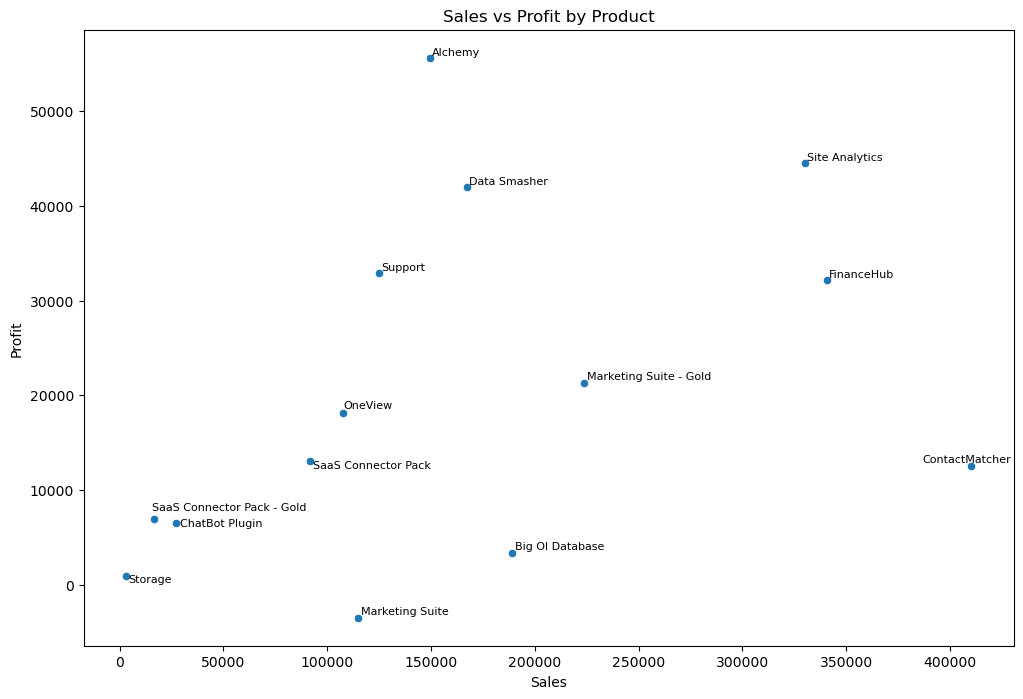

In [40]:
from adjustText import adjust_text

# Creating Scatter Plot for Sales vs Profit by Product
plt.figure(figsize=(12,8))
sns.scatterplot(data=product_full, x='Sales', y='Profit')

texts = []
for product, row in product_full.iterrows():
    texts.append(plt.text(row['Sales'], row['Profit'], product, fontsize=8))

adjust_text(texts)
plt.title("Sales vs Profit by Product")
plt.show()

Interpretation:

The scatter plot shows that not all high-revenue products generate high profit. While products such as `Alchemy`, `Data Smasher`, `FinanceHub`, and `Site Analytics` deliver strong profit, several top-selling products perform poorly from a profit standpoint. In particular, `ContactMatcher`, `Marketing Suite – Gold`, and `Big Ol Database` generate high sales but produce disproportionately low profit. This indicates that popularity alone does not translate into financial performance, and some high-volume products may be heavily discounted or priced inefficiently.

#### Sales vs Profit Margin

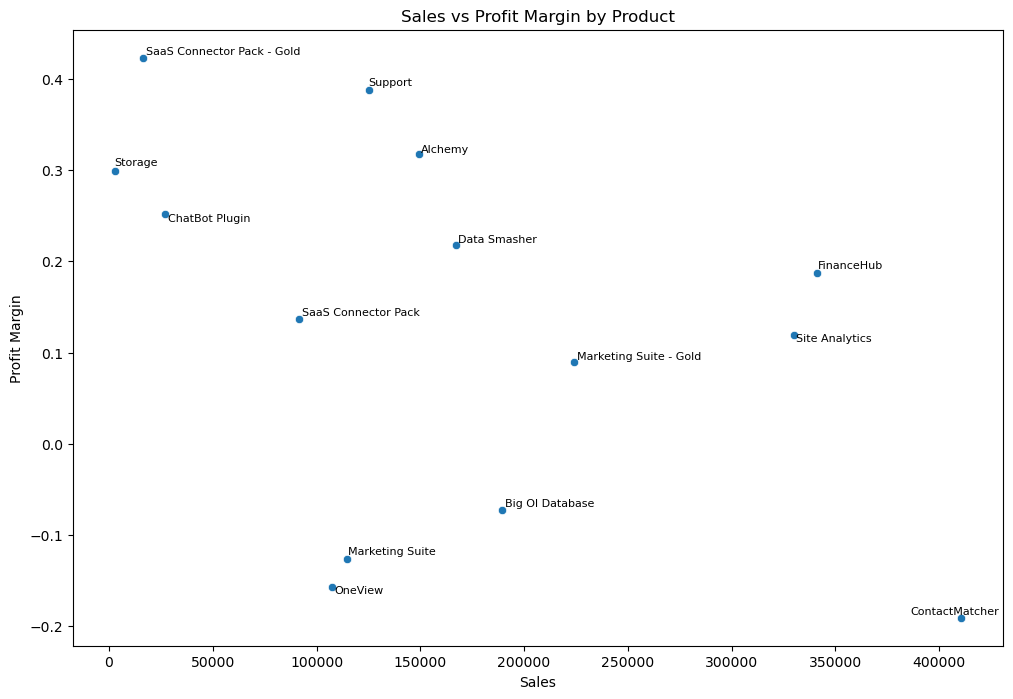

In [41]:
# Creating Scatter Plot for Sales vs Profit Margin by Product
plt.figure(figsize=(12,8))
sns.scatterplot(data=product_full, x='Sales', y='Profit Margin')

texts = []
for product, row in product_full.iterrows():
    texts.append(plt.text(row['Sales'], row['Profit Margin'], product, fontsize=8))

adjust_text(texts)
plt.title("Sales vs Profit Margin by Product")
plt.show()

Interpretation:

The relationship between sales and profit margin reveals clear differences in pricing efficiency. High-margin products such as `SaaS Connector Pack – Gold`, `Support`, `Alchemy`, `Storage`, and `ChatBot Plugin` demonstrate strong profitability despite lower sales volume. In contrast, several high-revenue products, including `ContactMatcher`, `OneView`, `Big Ol Database`, and `Marketing Suite`, show **negative** or **very low profit margins**, indicating inefficient pricing or heavy discounting. These products fall into the high-sales, low-margin “danger zone” and represent priority targets for pricing review.

### Product Performance Insight
The product performance analysis shows substantial variation in both revenue and profitability across the company’s portfolio. Several products—such as `ContactMatcher`, `FinanceHub`, and `Site Analytics`—are **major revenue drivers** and contribute significantly to total sales. However, a closer examination of profit and profit margin reveals that high sales volume does not always translate into strong financial performance.

To investigate this discrepancy, a filter was applied to identify products with high `Sales` (above median) but low `Profit Margin` (below median). These **high-sales, low-margin products** represent the greatest concern for profitability because they generate a large share of revenue while delivering disproportionately weak profit.

This filter flagged four key problematic products: `ContactMatcher`, `Site Analytics`, `Marketing Suite – Gold`, and `Big Ol Database`. These findings show that the company’s most financially risky products are not the low-selling items, but rather several of its most popular offerings. High demand combined with low margins suggests issues such as aggressive discounting, high support or operational costs, or misaligned pricing strategies.

In contrast, products like `Alchemy`, `Data Smasher`, and `FinanceHub` maintain strong profit margins while also generating meaningful revenue. These offerings represent stable and efficient components of the portfolio.

## Discount Impact
**Discounting** plays a major role in SaaS sales performance. High discounts reduce the final selling price and directly **lower profit**. In previous sections, several **products** and **subregions** showed low or negative margins, suggesting that discounting may be a major cause of **profitability inconsistencies**.

This section analyzes the relationship between `Discount`, `Profit`, and `Profit Margin`, with the goal of answering the business question:

“How do discounts affect profit margins?”

### Correlation Between Discount and Profit Margin

In [28]:
df[['Discount', 'Profit Margin']].corr()

,Discount,Profit Margin
Discount,1.000000,-0.864452
Profit Margin,-0.864452,1.000000


Interpretation:

The correlation analysis shows a **very strong negative relationship** between `Discount` and `Profit Margin`, with a coefficient of **–0.864**. This indicates that higher discounts are almost always associated with lower profitability. In many cases, deep discounting pushes profit margins close to zero or into negative territory. This confirms that **discounting is the primary driver** behind the company’s inconsistent and often weak profit margins.

### Visualizing Profit Margin Distribution by Discount Level

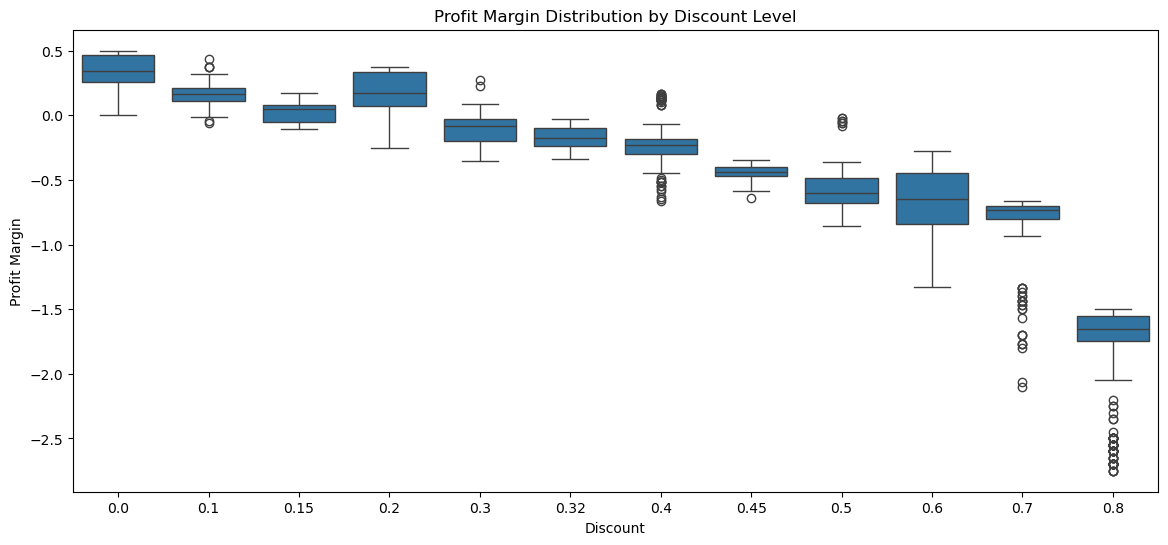

In [29]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df, x='Discount', y='Profit Margin')
plt.title("Profit Margin Distribution by Discount Level")
plt.show()

Interpretation:
* As `Discount` increases, **profitability** decreases, with **80%** discount way in the negatives and high number of negative outliers.
* **10-20%** discount is still manageable, with median still in the positive and box isn't too widespread.
* As expected, 0% discount has the highest `Profit Margin`, at minimum only **break even**.

### Average Discount by Subregion / Segment / Industry
This shows who receives bigger discounts.
#### By Subregion:

In [30]:
subregion_discount = df.groupby('Subregion')['Discount'].mean().sort_values(ascending=False)
subregion_discount

Subregion
JAPN       0.370193
ANZ        0.366919
EU-WEST    0.213662
LATAM      0.192401
EU-EAST    0.175802
NOR        0.146830
MEA        0.144192
NAMER      0.071001
UKIR       0.049250
APAC       0.011409
EU         0.000000
IND        0.000000
Name: Discount, dtype: float64

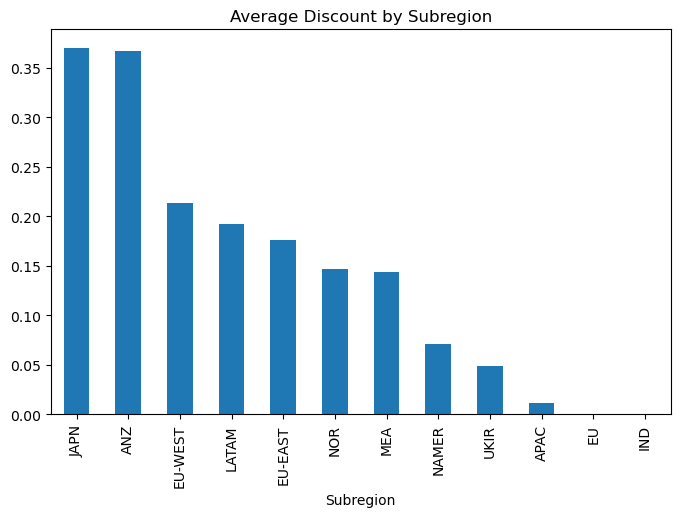

In [31]:
subregion_discount.plot(
    kind='bar',
    figsize=(8,5),
    title='Average Discount by Subregion')
plt.show()

Interpretation:
* `JAPN` and `ANZ` receive the heaviest discounts, which explain their **negative average profit margins**.
* `IND` and `EU` receive 0 `Discount`.
* `NAMER`, `UKIR`, and `APAC` have light discounts, which also explain their **high margins**.

#### By Segment:

In [32]:
segment_discount = df.groupby('Segment')['Discount'].mean().sort_values(ascending=False)
segment_discount

Segment
Strategic     0.158228
SMB           0.158141
Enterprise    0.147128
Name: Discount, dtype: float64

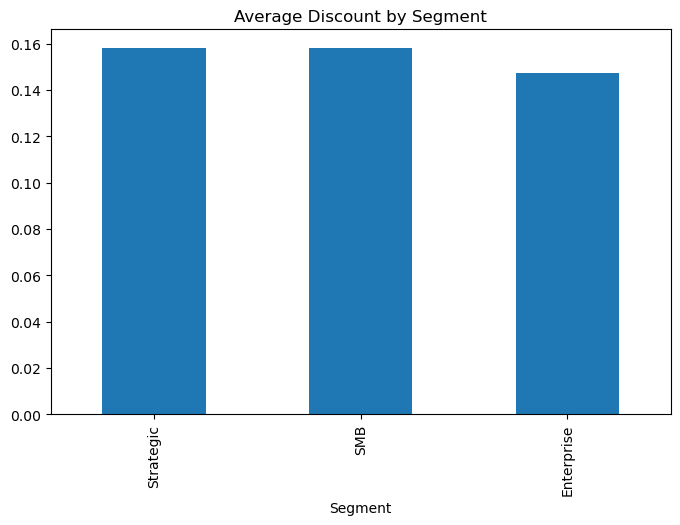

In [33]:
segment_discount.plot(
    kind='bar',
    figsize=(8,5),
    title='Average Discount by Segment')
plt.show()

Interpretation:

`Enterprise` slightly receives lower `Discount`, which matches their higher `Profit Margin`.

#### By Industry:

In [34]:
industry_discount = df.groupby('Industry')['Discount'].mean().sort_values(ascending=False)
industry_discount

Industry
Communications       0.164165
Consumer Products    0.162586
Energy               0.159947
Tech                 0.159094
Transportation       0.157179
Manufacturing        0.155385
Healthcare           0.155091
Finance              0.153644
Retail               0.145113
Misc                 0.140374
Name: Discount, dtype: float64

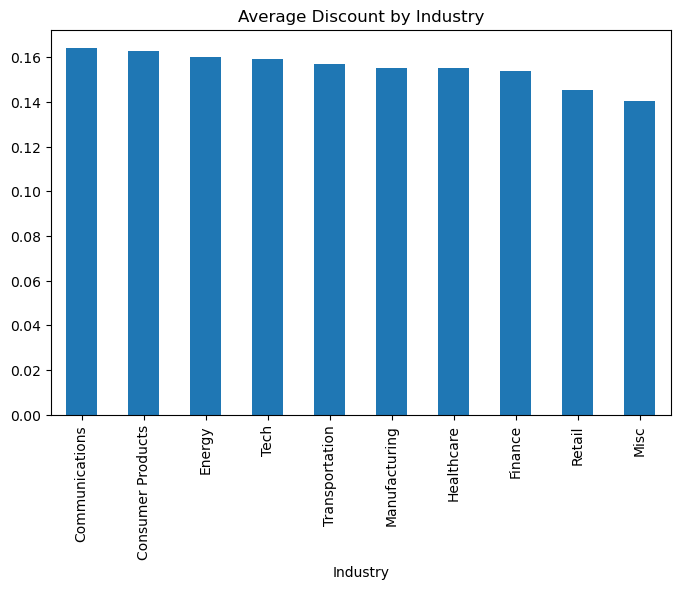

In [35]:
industry_discount.plot(
    kind='bar',
    figsize=(8,5),
    title='Average Discount by Industry')
plt.show()

Interpretation:
* Industries like `Communications` and `Consumer Products` demand the highest discounts.
* `Retail` and `Finance` receive lower discounts, supporting their **higher margins**.

### Average Discount by Product

In [36]:
product_discount = df.groupby('Product')['Discount'].mean().sort_values(ascending=False)
product_discount

Product
ContactMatcher                0.353067
Big Ol Database               0.306087
Marketing Suite               0.211140
OneView                       0.166524
Alchemy                       0.161765
Site Analytics                0.154556
SaaS Connector Pack           0.138349
FinanceHub                    0.132518
Storage                       0.082028
SaaS Connector Pack - Gold    0.080315
Data Smasher                  0.078452
Support                       0.075128
ChatBot Plugin                0.074874
Marketing Suite - Gold        0.074704
Name: Discount, dtype: float64

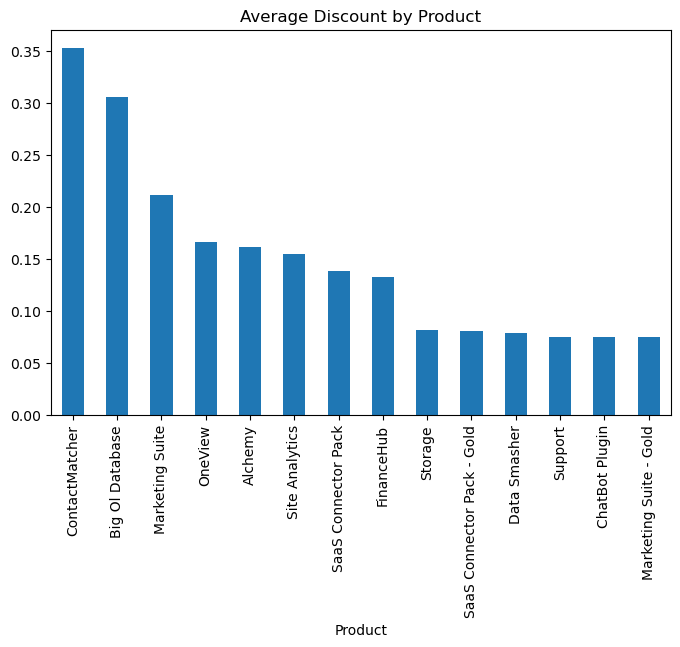

In [37]:
product_discount.plot(
    kind='bar',
    figsize=(8,5),
    title='Average Discount by Product')
plt.show()

Interpretation:
* The **heavily discounted products** include `ContactMatcher`, `Big Ol Database`, and `Marketing Suite`, which are some of the **problematic products**.
* `Alchemy`, `FinanceHub`, and `Data Smasher` have average to low discounts, and these products have **good profit margins**.

### Discount Impact Insight
The discount analysis reveals that discounting is the strongest and most consistent driver of low profitability in the company’s sales performance.

First, the correlation between discount and profit margin is extremely strong and negative (–0.864), indicating that higher discounts almost always lead to lower or even negative margins. This relationship is clearly visible in the profit margin distribution boxplot, where margins decline sharply and become more volatile as discount levels increase. At discount rates above 40–50%, most transactions produce negative margins, demonstrating that aggressive discounting directly undermines profitability.

Further analysis shows that discounting behavior varies significantly across customer groups. Strategic and SMB customers receive the highest average discounts, while Enterprise receives slightly less, supporting earlier observations that Enterprise margins are stronger. Industry-level differences are also notable: highly discounted industries such as Communications, Consumer Products, and Energy correspond to weaker profit margins, while lower-discount industries like Retail and Finance show healthier margins.

Subregion behavior aligns strongly with earlier findings. JAPN and ANZ receive the highest discounts and exhibit negative average profit margins, while IND receives no discount at all and maintains one of the highest margins. This suggests that certain geographic markets rely heavily on discounting to close deals, reducing profitability.

Product-level discounting further reinforces this pattern. Several heavily discounted products—such as ContactMatcher, Big Ol Database, and Marketing Suite—also appear in the high-sales but low-margin category. In contrast, products with low discount levels, such as Support and Data Smasher, consistently deliver strong margins.

Overall, the discount analysis confirms that heavy discounting is the primary factor behind the company’s inconsistent profitability. Managing discounting more strategically could significantly improve financial performance across products, customer groups, and regions.

# Conclusion and Recommendations
## Overall Summary of Findings
The analysis reveals that the company’s profitability varies significantly across regions, customer segments, industries, and products. While several products and geographic areas generate strong revenue, this does not always translate into healthy profit. The most consistent pattern across all analyses is that discounting heavily influences profit margin, often turning high-sales transactions into low-profit or negative-profit outcomes.

### Subregions
* Subregions such as `IND`, `UKIR`, and `NAMER` show strong and stable margins due to lower average discounting.
* In contrast, `JAPN` and `ANZ` exhibit wide profit margin volatility and frequent negative margins, driven by extremely high discount levels.
### Customer Segments & Industries
* `Enterprise` customers receive lower discounts and generate higher margins.
* `Strategic` and `SMB` segments receive higher discounts, resulting in lower margins despite contributing large total sales.
* Industries such as `Communications`, `Consumer Products`, `Energy`, and `Tech` are more price-sensitive, frequently requiring larger discounts.

### Product Performance
* Several high-revenue products—`ContactMatcher`, `Site Analytics`, `Marketing Suite – Gold`, `Big Ol Database`—have very **weak** or **negative profit margins**.
* These products fall into the **high-sales but low-margin “danger zone,”** making them critical targets for pricing or discount control.
* Conversely, products such as `Alchemy`, `Data Smasher`, `Support`, and `FinanceHub` maintain strong margins and represent efficient, profitable offerings.

### Discount Impact
* Discounting shows a very **strong negative correlation** with profit margin **(–0.864)**.
* Higher discount levels consistently produce lower or negative margins.
* Beyond 40–50% discount, margins become highly unstable and often negative, posing substantial financial risk.

## Conclusion
The analysis concludes that the primary reason for inconsistent profitability is **aggressive and uneven discounting across regions, customer types, industries, and products**. Even high-revenue products and subregions can underperform when discounts are excessive, while low-discount markets consistently yield healthier margins.

Improving profitability therefore requires the company to adopt a more **strategic, data-driven approach to discounting**. Addressing pricing inefficiencies, tightening discount thresholds, and focusing on high-margin offerings will significantly improve financial outcomes.

## Recommendations
1. Implement Discount Controls and Approval Limits
* Introduce tiered approval levels for discounts above 20%, 30%, and 40%.
* Restrict >50% discounting except for strategic deals with clear justification.
* Standardize discount policies across subregions to reduce uncontrolled variability.

2. Reevaluate Pricing for Low-Margin, High-Sales Products
Prioritize review of the following “danger zone” products:
* `ContactMatcher`
* `Site Analytics`
* `Marketing Suite – Gold`
* `Big Ol Database`

    Actions may include:
* Adjusting list price
* Reducing default discounts
* Repositioning product tiers
* Bundling with higher-margin products

3. Target High-Margin Products for Upselling & Promotion
Products with strong margins (e.g., `Alchemy`, `Data Smasher`, `Support`) should receive:
* Increased marketing focus
* Bundled promotions
* Sales incentives for reps
These products strengthen overall profitability when adopted widely.

4. Segment-Specific Pricing Strategy
* Reduce discounts in `SMB` by offering lower-cost entry packages instead of large reductions.
* Strengthen value communication for `Strategic` customers to reduce dependence on discounting.
* Encourage multi-year agreements in `Enterprise` where discounting is already lower.

5. Region-Specific Pricing Review
* Investigate extreme discounting practices in `JAPN` and `ANZ`, which strongly correlate with negative margins.
* Leverage insights from low-discount, high-margin regions (like `IND`, `NAMER`, `UKIR`) as benchmarks.
* Provide pricing training to regional sales teams.

6. Monitor Discounting with Regular Reporting
* Build dashboards tracking **discount level**, **profit margin**, and **deal profitability**.
* Identify transactions below defined margin thresholds in real time.
* Introduce quarterly reviews to adjust pricing strategy based on performance.

By addressing the root causes of discount-driven profit erosion and focusing on pricing discipline, the company can significantly improve its profitability without needing to increase sales volume. This analysis provides a clear, data-backed foundation for strategic pricing actions that enhance long-term financial performance.